In [1]:
import sys
sys.path.append('../')
from utils.MultiLabelPredictor import MultilabelPredictor
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, hamming_loss
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.spatial.distance import cosine
import seaborn as sns
from scipy.optimize import nnls

/home/massimo/Documents/stage/signature_inference/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def update_W_nnls_masked(V, H, mask):
    """
    Calcola W dato V e H fisso usando NNLS riga per riga,
    con vincolo: alcune componenti di W fissate a 0 (mask=0).

    V: (n_samples, n_features)
    H: (n_components, n_features)
    mask: (n_samples, n_components), valori binari (1=attiva, 0=fissata a 0)

    Ritorna:
    W: (n_samples, n_components)
    """
    n_samples, n_features = V.shape
    n_components = H.shape[0]
    W = np.zeros((n_samples, n_components))

    for i in range(n_samples):
        active_idx = np.where(mask[i] == 1)[0]   # firme attive per sample i
        if len(active_idx) == 0:
            continue  # nessuna firma attiva -> tutto zero

        A = H[active_idx].T   # (n_features, n_active)
        b = V[i, :]
        w_active, _ = nnls(A, b)

        # reinserisci nei posti giusti
        W[i, active_idx] = w_active

    return W

def evaluate_results(W, W_predicted):
    # R^2
    r2 = r2_score(W, W_predicted)

    # MSE
    mse = mean_squared_error(W, W_predicted)
    
    # MAE
    mae = mean_absolute_error(W, W_predicted)

    # Cosine distance (0 = identici, 1 = ortogonali)
    cos_similarity_per_patient = [1-cosine(W[i, :], W_predicted[i, :]) for i in range(W.shape[0])]
    mean_cos_similarity = np.mean(cos_similarity_per_patient)
    print(f"R2: {r2},\nMSE: {mse},\nMAE: {mae},\nCosine similarity: {mean_cos_similarity}")
    return cos_similarity_per_patient

In [4]:
V = np.array(pd.read_csv(f'../simulations/data2/run_1/trinucleotides_counts_sampling_{sampling_size}.csv').iloc[:, 1:].values)  # N x 96
active_signatures = pd.read_csv('../simulations/ground_truth/bin_exposures.csv').iloc[:, 1:].astype(int).values  # N x 29
alpha = np.array(pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:, 1:].values)  # N x 29
beta = np.array(pd.read_csv('../simulations/ground_truth/signatures.csv').iloc[:, 1:].values)

In [ ]:
sampling_size = '1'
## Importing the ground truth
sampling_name = f'trinucleotides_counts_sampling_{sampling_size}'
new_base_path = f'../models/saved_models/default/Predictor-{sampling_size}'

pred_mutation_count = pd.read_csv(f'../simulations/data2/run_1/{sampling_name}.csv', index_col=0)
# aggiorna i path per ogni label
predictor = MultilabelPredictor.load(new_base_path)
for label in predictor.labels:
    predictor.predictors[label] = os.path.join(new_base_path, f'Predictor_{label}')
    
predictions = np.array(predictor.predict(pred_mutation_count))
W = update_W_nnls_masked(V = V, H = beta, mask = predictions)

Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)
Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)
Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S1 (SBS1 - 0.99) ...
Predicting with TabularPredictor for label: S2 (SBS2 - 0.99) ...
Predicting with TabularPredictor for label: S3 (SBS3 - 0.97) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S4 (SBS4 - 0.98) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


...

Predicting with TabularPredictor for label: S27 (SBS88 - 0.92) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S28 (SBS92 - 0.95) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S29 (SBS97 - 0.95) ...


In [12]:
sig_profiler_assignment = pd.read_csv(f'../results/sigProfilerAssignment/spa_{sampling_name}/Assignment_Solution_Activities.txt', sep='\t', index_col=0)
sig_prof_prediction = np.array(sig_profiler_assignment)
sig_prof_prediction

array([[ 2193,  1382, 12152, ...,     0,     0,     0],
       [ 1545,     0,     0, ...,     0,     0,     0],
       [  687,     0,     0, ...,     0,     0,     0],
       ...,
       [  164,     0,     0, ...,     0,     0,     0],
       [  941,   328,     0, ...,     0,     0,     0],
       [  941,     0,     0, ...,     0,     0,     0]], shape=(18119, 29))

In [19]:
musical_df = pd.read_csv(f'../results/musical/musical_preidction_{sampling_size}.txt', index_col=0).T
musical_prediction = np.array(musical_df)
musical_prediction

array([[1566.99644705, 1177.63062719, 5613.9529141 , ...,    0.        ,
           0.        ,    0.        ],
       [1565.9664959 ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [ 620.76665545,   80.45601011,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       ...,
       [ 156.86475527,   11.94812783,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [ 666.65770734,  180.66427344,  674.1358702 , ...,  157.65521801,
         352.1710559 ,    0.        ],
       [ 757.70630779,    0.        ,  245.62517807, ...,  153.02912018,
           0.        ,    0.        ]], shape=(18119, 29))

In [ ]:
cos_similarity_with_prediction = evaluate_results(alpha, W)

cos_sim_sig_prof = evaluate_results(alpha, sig_prof_prediction)

cos_sim_musical = evaluate_results(alpha, musical_prediction)

R2: 0.6416967496377289,
MSE: 9273957.407895613,
MAE: 133.0536735459472,
Cosine similarity: 0.9792429159613691
R2: 0.3235679551879867,
MSE: 9879771.607559215,
MAE: 354.2014874614149,
Cosine similarity: 0.8971332503683936
R2: 0.7353370082883027,
MSE: 3200499.139697408,
MAE: 172.31143264623634,
Cosine similarity: 0.95803254388983


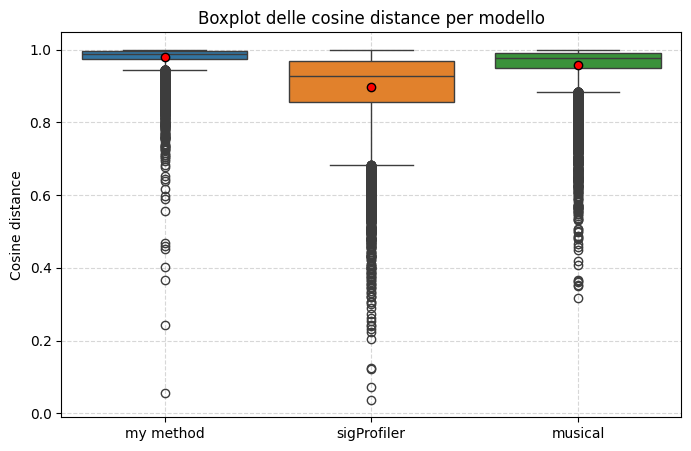

In [38]:
cos_dists = [cos_similarity_with_prediction, cos_sim_sig_prof, cos_sim_musical]
labels = ['my method', 'sigProfiler', 'musical']
plt.figure(figsize=(8,5))
sns.boxplot(data=cos_dists, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black"})
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.ylabel("Cosine distance")
plt.title("Boxplot delle cosine distance per modello")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

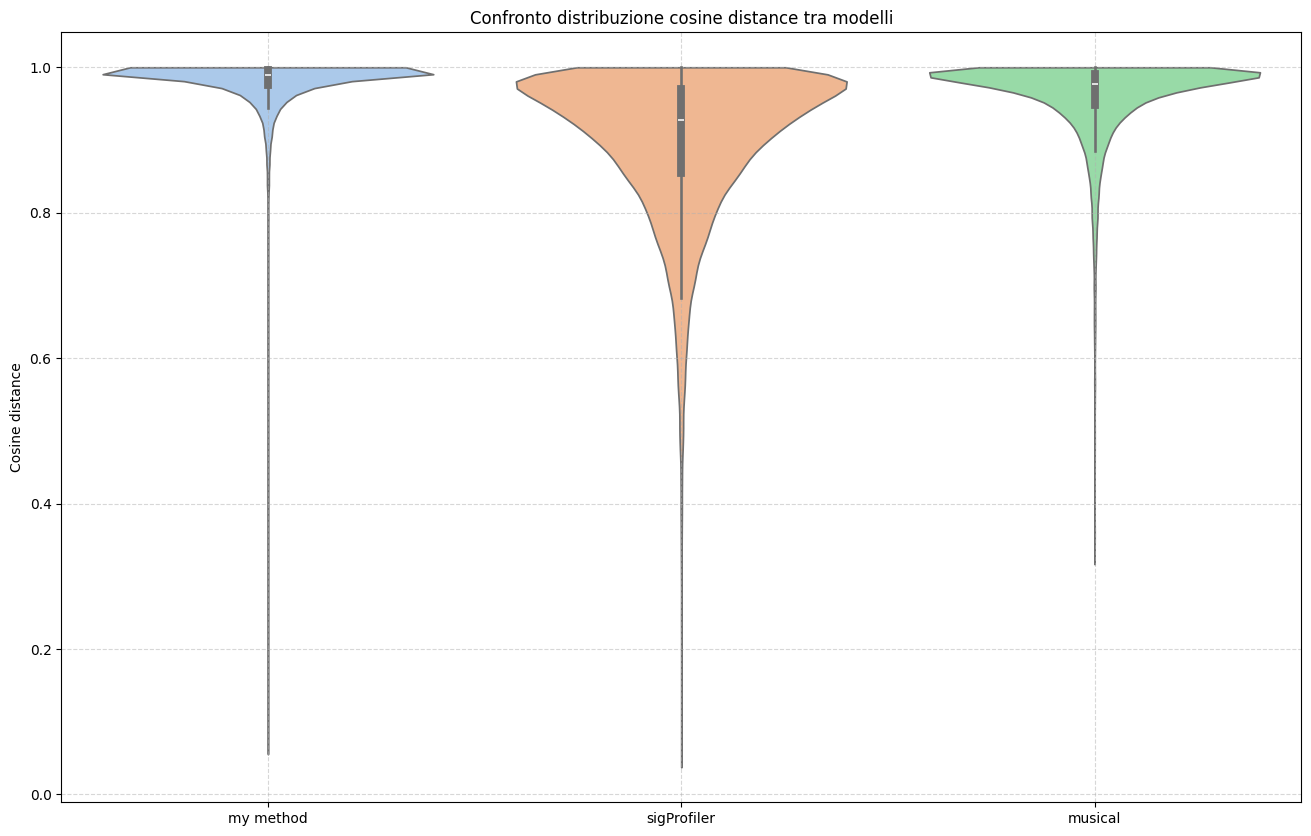

In [25]:
plt.figure(figsize=(16, 10))
sns.violinplot(data=cos_dists, inner="box", cut=0, palette="pastel")
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.ylabel("Cosine distance")
plt.title("Confronto distribuzione cosine distance tra modelli")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()